In [29]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [30]:
data = load_breast_cancer()
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [31]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [32]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [33]:
#Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)
N, D = X_train.shape

In [34]:
#Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
#Build model
model = nn.Sequential(
    nn.Linear(D, 1),
    nn.Sigmoid())

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())



In [36]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32).reshape(-1,1))
y_test = torch.from_numpy(y_test.astype(np.float32).reshape(-1,1))

In [37]:
#Train loop

epochs = 1000
train_losses = np.zeros(epochs)
test_losses = np.zeros(epochs)

for i in range(epochs):
    optimizer.zero_grad()
    
    #Forward pass
    output = model(X_train)
    loss = criterion(output, y_train)
    
    #Backward and optimize
    loss.backward()
    optimizer.step()
    
    #Test loss
    output_test = model(X_test)
    loss_test = criterion(output_test, y_test)
    
    #Save losses
    train_losses[i] = loss.item()
    test_losses[i] = loss_test.item()
    
    if (i + 1) % 50 == 0:
        print(f'Epoch {i+1}/{epochs}, Train loss: {loss.item():4f}, Test loss: {loss_test.item():4f}')

Epoch 50/1000, Train loss: 0.423428, Test loss: 0.424595
Epoch 100/1000, Train loss: 0.322017, Test loss: 0.342810
Epoch 150/1000, Train loss: 0.262598, Test loss: 0.293571
Epoch 200/1000, Train loss: 0.224129, Test loss: 0.259494
Epoch 250/1000, Train loss: 0.197378, Test loss: 0.234199
Epoch 300/1000, Train loss: 0.177763, Test loss: 0.214550
Epoch 350/1000, Train loss: 0.162784, Test loss: 0.198770
Epoch 400/1000, Train loss: 0.150976, Test loss: 0.185774
Epoch 450/1000, Train loss: 0.141424, Test loss: 0.174856
Epoch 500/1000, Train loss: 0.133532, Test loss: 0.165537
Epoch 550/1000, Train loss: 0.126892, Test loss: 0.157478
Epoch 600/1000, Train loss: 0.121219, Test loss: 0.150429
Epoch 650/1000, Train loss: 0.116310, Test loss: 0.144205
Epoch 700/1000, Train loss: 0.112011, Test loss: 0.138664
Epoch 750/1000, Train loss: 0.108211, Test loss: 0.133695
Epoch 800/1000, Train loss: 0.104820, Test loss: 0.129210
Epoch 850/1000, Train loss: 0.101773, Test loss: 0.125140
Epoch 900/1000,

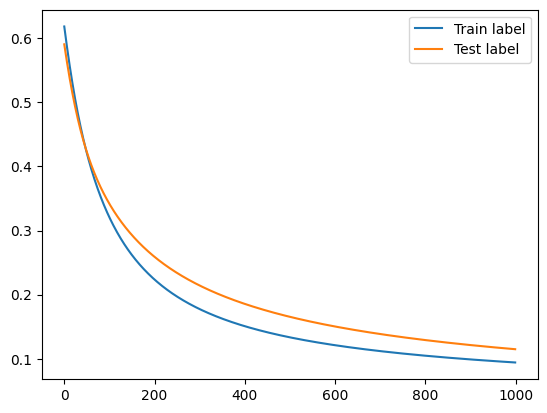

In [40]:
plt.plot(train_losses, label = 'Train label')
plt.plot(test_losses, label = 'Test label')
plt.legend()
plt.show()

In [41]:
#Check accuracy
with torch.no_grad():
    p_train = model(X_train)
    p_train = np.round(p_train.numpy())
    train_acc = np.mean(y_train.numpy() == p_train)
    
    p_test = model(X_test)
    p_test = np.round(p_test.numpy())
    test_acc = np.mean(y_test.numpy() == p_test)

print(f'Train accuracy: {train_acc}, Test accuracy: {test_acc}')

Train accuracy: 0.979002624671916, Test accuracy: 0.9680851063829787
